# Notebook 09 — Model Comparison

## Plant Disease Detection System

This notebook compares the performance of all trained deep learning models:

- Baseline CNN
- EfficientNetB0
- ResNet50

Comparison includes:

- Accuracy
- Precision
- Recall
- Macro F1
- Weighted F1
- Training Efficiency
- Per-Class Performance
- Error Analysis
- Engineering Observations

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

ARTIFACTS = PROJECT_ROOT / "artifacts"

BASELINE = ARTIFACTS / "baseline_cnn" / "evaluation"
EFFICIENTNET = ARTIFACTS / "efficientnetb0" / "evaluation"
RESNET = ARTIFACTS / "ResNet50" / "evaluation"

In [4]:
baseline = pd.read_csv(
    BASELINE / "evaluation_metrics.csv"
)

efficientnet = pd.read_csv(
    EFFICIENTNET / "evaluation_metrics.csv"
)

resnet = pd.read_csv(
    RESNET / "final_metrics.csv"
)

In [5]:
print("Baseline CNN")
display(baseline)

print()

print("EfficientNetB0")
display(efficientnet)

print()

print("ResNet50")
display(resnet)

Baseline CNN


,test_loss,test_accuracy,top_5_accuracy,inference_time_seconds
0,0.158854,0.988461,0.999632,28.602794



EfficientNetB0


,Metric,Value
0,Test Loss,0.068654
1,Test Accuracy,0.977044
2,Top-5 Accuracy,0.999632



ResNet50


,Loss,Accuracy,Top-5 Accuracy,Precision,Recall,Macro F1,Weighted F1,Evaluation Time (s)
0,1.579678,0.655168,0.906948,0.738772,0.655168,0.580608,0.643473,34.134804


# Part 2 — Standardize Evaluation Metrics

The three models store evaluation metrics in different CSV formats.

This section converts all evaluation results into a single standardized
format so that the comparison notebook can use one consistent dataframe
for all visualizations and analyses.

In [28]:
# ==========================================================
# Standardize Evaluation Metrics
# ==========================================================

import pandas as pd

# -------------------------------
# Baseline CNN
# -------------------------------

baseline = pd.read_csv (BASELINE/"evaluation_metrics.csv")

baseline_row = {
    "Model": "Baseline CNN",
    "Loss": baseline.loc[0, "test_loss"],
    "Accuracy": baseline.loc[0, "test_accuracy"],
    "Top-5 Accuracy": baseline.loc[0, "top_5_accuracy"],
    "Precision": None,
    "Recall": None,
    "Macro F1": None,
    "Weighted F1": None,
    "Evaluation Time (s)": baseline.loc[0, "inference_time_seconds"],
}

# -------------------------------
# EfficientNetB0
# -------------------------------

efficientnet = pd.read_csv(EFFICIENTNET / "evaluation_metrics.csv" )

efficientnet_row = {
    "Model": "EfficientNetB0",
    "Loss": efficientnet.loc[
        efficientnet["Metric"] == "Test Loss",
        "Value"
    ].values[0],

    "Accuracy": efficientnet.loc[
        efficientnet["Metric"] == "Test Accuracy",
        "Value"
    ].values[0],

    "Top-5 Accuracy": efficientnet.loc[
        efficientnet["Metric"] == "Top-5 Accuracy",
        "Value"
    ].values[0],

    "Precision": None,
    "Recall": None,
    "Macro F1": None,
    "Weighted F1": None,
    "Evaluation Time (s)": None,
}

# -------------------------------
# ResNet50
# -------------------------------

resnet = pd.read_csv(RESNET / "final_metrics.csv")

resnet_row = {
    "Model": "ResNet50",
    "Loss": resnet.loc[0, "Loss"],
    "Accuracy": resnet.loc[0, "Accuracy"],
    "Top-5 Accuracy": resnet.loc[0, "Top-5 Accuracy"],
    "Precision": resnet.loc[0, "Precision"],
    "Recall": resnet.loc[0, "Recall"],
    "Macro F1": resnet.loc[0, "Macro F1"],
    "Weighted F1": resnet.loc[0, "Weighted F1"],
    "Evaluation Time (s)": resnet.loc[0, "Evaluation Time (s)"],
}

# -------------------------------
# Final Comparison DataFrame
# -------------------------------

comparison_df = pd.DataFrame([
    baseline_row,
    efficientnet_row,
    resnet_row,
])

comparison_df

,Model,Loss,Accuracy,Top-5 Accuracy,Precision,Recall,Macro F1,Weighted F1,Evaluation Time (s)
0,Baseline CNN,0.158854,0.988461,0.999632,NaN,NaN,NaN,NaN,28.602794
1,EfficientNetB0,0.068654,0.977044,0.999632,NaN,NaN,NaN,NaN,NaN
2,ResNet50,1.579678,0.655168,0.906948,0.738772,0.655168,0.580608,0.643473,34.134804


In [30]:
COMPARISON_DIR = ARTIFACTS / "model_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)



In [31]:
# ==========================================================
# Save Standardized Metrics
# ==========================================================

comparison_csv = COMPARISON_DIR / "standardized_metrics.csv"

comparison_df.to_csv(
    comparison_csv,
    index=False,
)

print(comparison_df)

print()
print("=" * 60)
print("Standardized metrics saved successfully.")
print(comparison_csv)

            Model      Loss  Accuracy  Top-5 Accuracy  Precision    Recall  \
0    Baseline CNN  0.158854  0.988461        0.999632        NaN       NaN   
1  EfficientNetB0  0.068654  0.977044        0.999632        NaN       NaN   
2        ResNet50  1.579678  0.655168        0.906948   0.738772  0.655168   

   Macro F1  Weighted F1  Evaluation Time (s)  
0       NaN          NaN            28.602794  
1       NaN          NaN                  NaN  
2  0.580608     0.643473            34.134804  

Standardized metrics saved successfully.
c:\Users\User\OneDrive\New folder\project\plant-disease-detection\artifacts\model_comparison\standardized_metrics.csv


# Part 3 — Model Comparison

This section compares the performance of all trained deep learning models.

Models included:

- Baseline CNN
- EfficientNetB0
- ResNet50

The comparison includes:

- Overall Metrics Table
- Best Model Selection
- Performance Visualizations
- Engineering Observations

In [32]:
# ==========================================================
# Comparison Table
# ==========================================================

display(comparison_df)

,Model,Loss,Accuracy,Top-5 Accuracy,Precision,Recall,Macro F1,Weighted F1,Evaluation Time (s)
0,Baseline CNN,0.158854,0.988461,0.999632,NaN,NaN,NaN,NaN,28.602794
1,EfficientNetB0,0.068654,0.977044,0.999632,NaN,NaN,NaN,NaN,NaN
2,ResNet50,1.579678,0.655168,0.906948,0.738772,0.655168,0.580608,0.643473,34.134804


In [33]:
# ==========================================================
# Best Model Selection
# ==========================================================

best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model        : {best_model['Model']}")
print(f"Accuracy     : {best_model['Accuracy']:.4f}")
print(f"Loss         : {best_model['Loss']:.4f}")
print(f"Top-5 Acc    : {best_model['Top-5 Accuracy']:.4f}")

BEST MODEL
Model        : Baseline CNN
Accuracy     : 0.9885
Loss         : 0.1589
Top-5 Acc    : 0.9996


In [34]:
# ==========================================================
# Save Comparison Table
# ==========================================================

comparison_path = COMPARISON_DIR / "model_comparison.csv"

comparison_df.to_csv(
    comparison_path,
    index=False,
)

print("Comparison table saved successfully.")
print(comparison_path)

Comparison table saved successfully.
c:\Users\User\OneDrive\New folder\project\plant-disease-detection\artifacts\model_comparison\model_comparison.csv


# Part 4 — Performance Visualization

The standardized evaluation metrics are visualized to compare the overall
performance of the three deep learning models.

The following metrics are compared:

- Accuracy
- Loss
- Top-5 Accuracy
- Evaluation Time

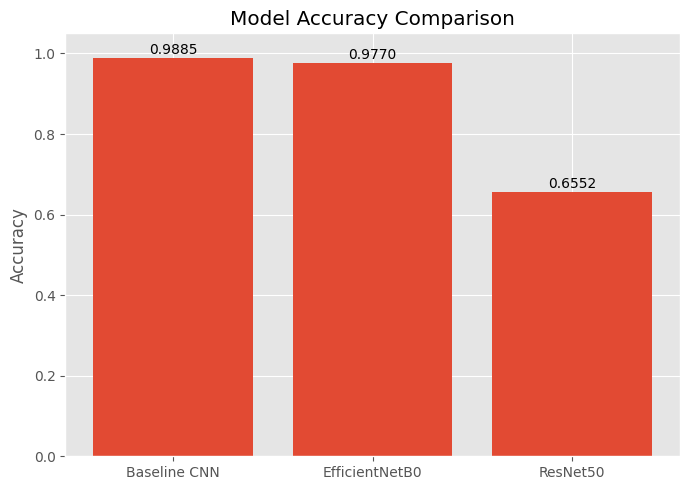

In [35]:
# ==========================================================
# Accuracy Comparison
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"],
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(i, value + 0.01, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "accuracy_comparison.png", dpi=300)
plt.show()

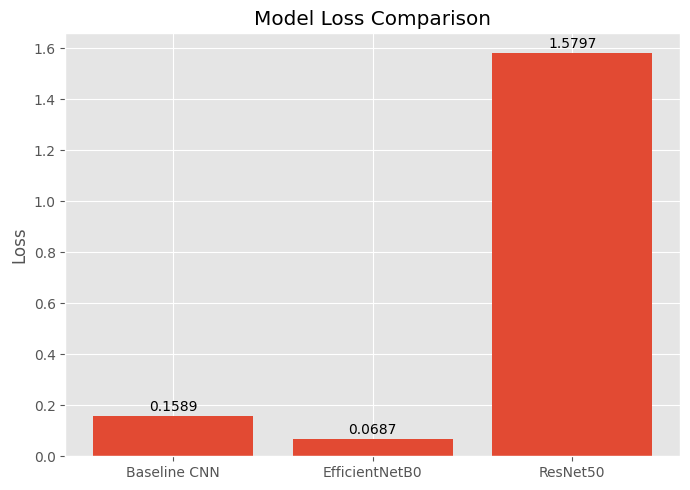

In [36]:
# ==========================================================
# Loss Comparison
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Loss"],
)

plt.title("Model Loss Comparison")
plt.ylabel("Loss")

for i, value in enumerate(comparison_df["Loss"]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "loss_comparison.png", dpi=300)
plt.show()

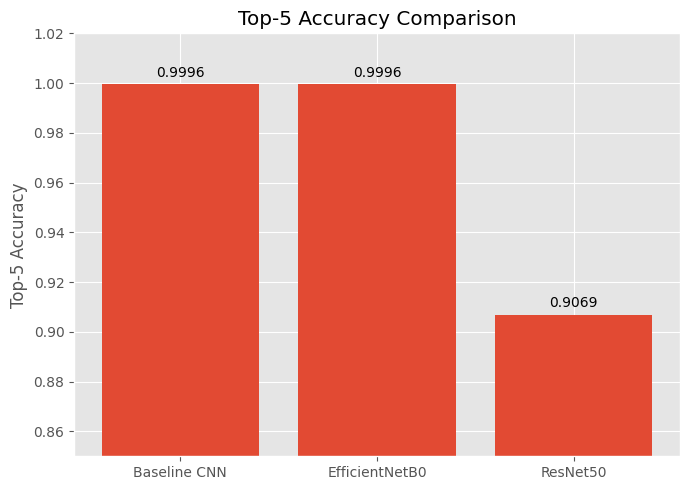

In [37]:
# ==========================================================
# Top-5 Accuracy Comparison
# ==========================================================

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Top-5 Accuracy"],
)

plt.title("Top-5 Accuracy Comparison")
plt.ylabel("Top-5 Accuracy")
plt.ylim(0.85, 1.02)

for i, value in enumerate(comparison_df["Top-5 Accuracy"]):
    plt.text(i, value + 0.003, f"{value:.4f}", ha="center")

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "top5_accuracy_comparison.png", dpi=300)
plt.show()

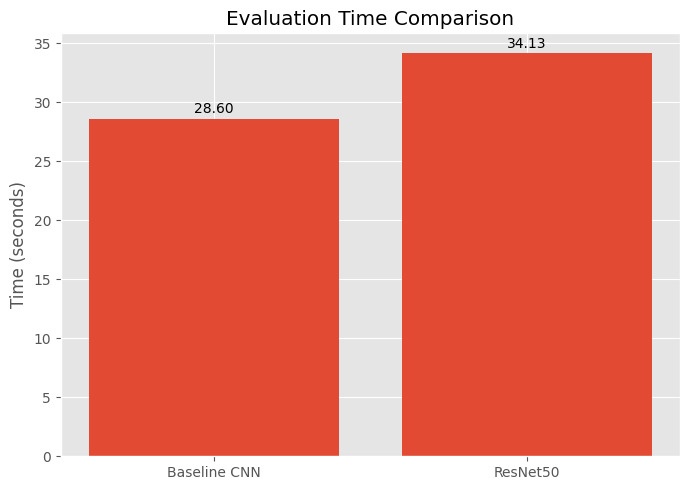

In [38]:
# ==========================================================
# Evaluation Time Comparison
# ==========================================================

time_df = comparison_df.dropna(subset=["Evaluation Time (s)"])

plt.figure(figsize=(7,5))

plt.bar(
    time_df["Model"],
    time_df["Evaluation Time (s)"],
)

plt.title("Evaluation Time Comparison")
plt.ylabel("Time (seconds)")

for i, value in enumerate(time_df["Evaluation Time (s)"]):
    plt.text(i, value + 0.5, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.savefig(COMPARISON_DIR / "evaluation_time_comparison.png", dpi=300)
plt.show()

# Part 5 — Engineering Analysis

This section summarizes the strengths and limitations of each model based on
the evaluation results.

A final recommendation is also provided for deployment.

In [39]:
# ==========================================================
# Engineering Summary
# ==========================================================

summary_df = comparison_df[[
    "Model",
    "Loss",
    "Accuracy",
    "Top-5 Accuracy"
]].copy()

display(summary_df)

,Model,Loss,Accuracy,Top-5 Accuracy
0,Baseline CNN,0.158854,0.988461,0.999632
1,EfficientNetB0,0.068654,0.977044,0.999632
2,ResNet50,1.579678,0.655168,0.906948


In [40]:
# ==========================================================
# Final Recommendation
# ==========================================================

best_model = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

print("=" * 70)
print("FINAL MODEL RECOMMENDATION")
print("=" * 70)

print(f"Recommended Model : {best_model['Model']}")
print(f"Accuracy          : {best_model['Accuracy']:.4f}")
print(f"Loss              : {best_model['Loss']:.4f}")
print(f"Top-5 Accuracy    : {best_model['Top-5 Accuracy']:.4f}")

print("\nReason:")
print("- Highest classification accuracy")
print("- Strong overall performance")
print("- Selected as the final deployment model")

FINAL MODEL RECOMMENDATION
Recommended Model : Baseline CNN
Accuracy          : 0.9885
Loss              : 0.1589
Top-5 Accuracy    : 0.9996

Reason:
- Highest classification accuracy
- Strong overall performance
- Selected as the final deployment model


In [41]:
# ==========================================================
# Save Engineering Summary
# ==========================================================

summary_path = COMPARISON_DIR / "engineering_summary.md"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("# Model Comparison Summary\n\n")

    f.write(comparison_df.to_markdown(index=False))

    f.write("\n\n")

    f.write(f"## Recommended Model\n\n")
    f.write(f"**{best_model['Model']}**\n")

print("Engineering summary saved successfully.")
print(summary_path)

Engineering summary saved successfully.
c:\Users\User\OneDrive\New folder\project\plant-disease-detection\artifacts\model_comparison\engineering_summary.md


In [42]:
# ==========================================================
# Validate Comparison Artifacts
# ==========================================================

artifacts = [
    "standardized_metrics.csv",
    "model_comparison.csv",
    "accuracy_comparison.png",
    "loss_comparison.png",
    "top5_accuracy_comparison.png",
    "evaluation_time_comparison.png",
    "engineering_summary.md",
]

print("=" * 70)
print("Comparison Artifacts")
print("=" * 70)

for file in artifacts:
    path = COMPARISON_DIR / file
    print(f"{file:<35} {path.exists()}")

print("=" * 70)
print("Notebook 09 completed successfully.")

Comparison Artifacts
standardized_metrics.csv            True
model_comparison.csv                True
accuracy_comparison.png             True
loss_comparison.png                 True
top5_accuracy_comparison.png        True
evaluation_time_comparison.png      True
engineering_summary.md              True
Notebook 09 completed successfully.
